# EO-LINCS project: Cube generation for Scientific Case Study (SCS) 2

## Forest recovery post disturbance

**Objective**: The SCS2 aims to estimate canopy height and above-ground biomass maps using deep learning methods based on remote sensing data. The canopy height and above-ground biomass maps are subsequently used to calculate recovery curves, which in turn can be used to estimate carbon budget.

**Outcomes**: New high-resolution height/biomass maps that are expected to enable the monitoring of biomass 
at finer scales, in particular the impact of fine scale forest disturbances due to management practices such as 
thinning and the impact of natural disturbances (insects attacks, droughts, fires and windthrown in regions of 
interest). Analysis of forest recovery depending on environmental factors (such as climate, soil composition 
and pH) and the nature and intensity of disturbance shall aid in the optimization of forest management 
considering potential increased future disturbances.

**Required Datasets**:
* [Global Age Mapping Integration (GAMI) dataset](https://gfzpublic.gfz-potsdam.de/pubman/faces/ViewItemOverviewPage.jsp?itemId=item_5029361)
* [European Forest Disturbance Atlas](https://zenodo.org/records/8389086)
* [Canopy height and biomass map for Europe](https://zenodo.org/records/8154445)  
* [Copernicus Tree cover density 2015](https://land.copernicus.eu/en/products/high-resolution-layer-tree-cover-density/tree-cover-density-2015)  
* [Copernicus Dominant Leaf Type 2015](https://land.copernicus.eu/en/products/high-resolution-layer-dominant-leaf-type/dominant-leaf-type-2015)  
* [Copernicus Forest Type 2015](https://land.copernicus.eu/en/products/high-resolution-layer-forest-type/forest-type-2015) 

-------------------------------------------------------------

The following notebook shows how the users can load data from various sources defined in `scs2_config.yml` using the `MultiSourceDataStore` tool.

#### **What You Can Do with This Notebook** 
- Load datasets from various sources as defined in the `scs2_config.yml`
- View the progress of each data request to the `MultiSourceDataStore`
- Quickly preview the datasets by downsampling and plotting them.

### **Requirements**  
Before you begin, ensure that all necessary dependencies are installed and that you have generated API token credentials for CLMS:  

- Install `xcube-multistore` via conda-forge by running: `conda install --channel conda-forge xcube-multistore`
- Generate CLMS API token credentials by following the [offical instructions](https://eea.github.io/clms-api-docs/authentication.html). Save the credentials in a file named `clms-credentials.json`, placing it in the same directory as this notebook. Note that the filename can be customized in the `scs2_config.yml` configuration file.

Once you have it installed, you are ready to proceed.

This Multistore mainly works with a file called `scs2_config.yml` which is at the same file level as this notebook.
To understand what goes into the schema, you can read more [here](https://xcube-dev.github.io/xcube-multistore/).

-------------------------------------------------------

Let's import the `MultiSourceDataStore`

In [1]:
from xcube_multistore import MultiSourceDataStore

In [2]:
from dask.distributed import Client, LocalCluster
import dask

cluster = LocalCluster(
    n_workers=4,              
    threads_per_worker=2,
    memory_limit='4GB', # per worker
)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41791,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42661,Total threads: 2
Dashboard: http://127.0.0.1:41413/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:44367,


2025-10-30 15:57:02,475 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:8787', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/home/konstantin/micromamba/envs/xcube-multistore/lib/python3.13/site-packages/tornado/web.py", line 1790, in _execute
    result = await result
             ^^^^^^^^^^^^
  File "/home/konstantin/micromamba/envs/xcube-multistore/lib/python3.13/site-packages/tornado/websocket.py", line 273, in get
    await self.ws_connection.accept_connection(self)
  File "/home/konstantin/micromamba/envs/xcube-multistore/lib/python3.13/site-packages/tornado/websocket.py", line 863, in accept_connection
    await self._accept_connection(handler)
  File "/home/konstantin/micromamba/envs/xcube-multistore/lib/python3.13/site-packages/tornado/websocket.py", line 946, in _accept_connection
    await self._receive_frame_loop()
  File "

You can find out how to fill out the config file by also using this super helpful function `get_config_schema()`. Run it and try expand the fields to learn more about the possible properties that the configuration file accepts along with the [Configuration Guide](https://xcube-dev.github.io/xcube-multistore/config/).

In [3]:
MultiSourceDataStore.get_config_schema()

To set up the config file, please refer to the notebook [setup_config.ipynb](../setup_config.ipynb) or the [Configuration Guide](https://xcube-dev.github.io/xcube-multistore/config/) in the documentation.

We can view the configuration using the method `display_config`, executing the follwoing cell. It shows, that for the user-defined dataset ID `clms` and `senf`, some data fusion of multiple data sources will be performed.

In [5]:
msds = MultiSourceDataStore("scs2_config.yml")

In [6]:
msds.display_config()

User-defined ID,Data Store ID,Data Store Params,Data ID,Open Data Params,Grid-Mapping,Format
clms,clms,credentials: clms-credentials.json,tree-cover-density-2015|TCD_2015_020m_eu_03035_d05_E30N20.zarr,-,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 1000",Zarr
clms,clms,credentials: clms-credentials.json,dominant-leaf-type-2015|DLT_2015_020m_eu_03035_d04_E30N20.zarr,-,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 1000",Zarr
clms,clms,credentials: clms-credentials.json,forest-type-2015|FTY_2015_020m_eu_03035_d04_E30N20.zarr,-,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 1000",Zarr
senf,zenodo,root: 13333034,france/annual_disturbances_1985_2023_france.tif,-,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 1000",Zarr
senf,zenodo,root: 13333034,france/disturbance_agent_1985_2023_france.tif,-,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 1000",Zarr
senf,zenodo,root: 13333034,france/greatest_disturbance_france.tif,-,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 1000",Zarr
senf,zenodo,root: 13333034,france/forest_mask_france.tif,-,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 1000",Zarr
senf,zenodo,root: 13333034,france/disturbance_agent_aggregated_france.tif,-,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 1000",Zarr
senf,zenodo,root: 13333034,france/latest_disturbance_france.tif,-,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 1000",Zarr
senf,zenodo,root: 13333034,france/number_disturbances_france.tif,-,"bbox: [-1.25, 43.5, 0.5, 44.8]; spatial_res: 0.00025; crs: EPSG:4326; tile_size: 1000",Zarr


In [7]:
msds.display_geolocations()

Now, we can initialize the `MultiSourceDataStore` by passing the path to the `scs2_config.yml` which currently is on the same level as this notebook. 

By running the cell below, you would start seeing progress tables for each data that you requested in the `scs2_config.yml`.

**NOTE**: In the `scs2_config.yml` we are also using the `custom_processing` feature of this tool that allows us to run a function for processing each dataset separately. In this example, we have defined a module called `modify_dataset` that does some custom processing which takes a `xarray.Dataset` argument as input and returns a new `xarray.Dataset` object. To read more about this `custom_processing` function, you can see more [here](https://xcube-dev.github.io/xcube-multistore/config/#custom_processing).

In [ ]:
msds.generate()

Dataset identifier,Status,Message,Exception
france.zip,COMPLETED,Already preloaded.,-


Dataset identifier,Status,Message,Exception
tree-cover-density-2015|TCD_2015_020m_eu_03035_d05_E30N20,COMPLETED,Already preloaded.,-
dominant-leaf-type-2015|DLT_2015_020m_eu_03035_d04_E30N20,COMPLETED,Already preloaded.,-
forest-type-2015|FTY_2015_020m_eu_03035_d04_E30N20,COMPLETED,Already preloaded.,-


Dataset identifier,Status,Message,Exception
clms,COMPLETED,Dataset 'clms' already generated.,-
senf,STARTED,Processing dataset 'senf'.,-
gami,WAITING,-,-
liu,WAITING,-,-


2025-10-30 16:04:19,623 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-10-30 16:04:19,623 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-10-30 16:04:19,623 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
2025-10-30 16:04:19,623 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/konstantin/micromamba/envs/xcube-multistore/lib/python3.13/asyncio/runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "/home/konstantin/micromamba/envs/xcube-multistore/lib/python3.13/asyncio/base_events.py", line 725, in run_until_complete
    retur

We can now open the data using the xcube datastore framework API as usual. Note that the multi-source data store requires a data store called `storage`, which is configured in our `scs2_config.yml` under the `data_stores` section.

In [5]:
ds = msds.stores.storage.open_data("gami.zarr")
ds

<xarray.Dataset> Size: 3GB
Dimensions:      (members: 20, time: 2, latitude: 5199, longitude: 7000)
Coordinates:
  * latitude     (latitude) float64 42kB 44.8 44.8 44.8 44.8 ... 43.5 43.5 43.5
  * longitude    (longitude) float64 56kB -1.25 -1.25 -1.249 ... 0.4996 0.4999
  * members      (members) int64 160B 0 1 2 3 4 5 6 7 ... 13 14 15 16 17 18 19
    spatial_ref  int64 8B ...
  * time         (time) datetime64[ns] 16B 2010-01-01 2020-01-01
Data variables:
    forest_age   (members, time, latitude, longitude) int16 3GB dask.array<chunksize=(5, 1, 1000, 1000), meta=np.ndarray>
Attributes: (12/21)
    _FillValue:                 -9999
    contact:                    Simon Besnard (besnard@gfz.de) and Nuno Carva...
    created_by:                 Simon Besnard
    creation_date:              2025-01-31 16:52
    date_modified:              2025-09-11T14:51:07.671612
    frequency:                  2010 and 2020
    ...                         ...
    geospatial_lon_units:       degrees_east
    institute_id:               GFZ-Potsdam and MPI-BGC
    institution:                Helmholtz Center Potsdam GFZ German Research ...
    product_name:               Global Age Mapping Integration (GAMI) v2.1
    references:                 https://doi.org/10.5880/GFZ.1.4.2023.006 and ...
    version:                    v2.1

We can now select a variable for one timestep, downsample and plot it for a quick preview of the data

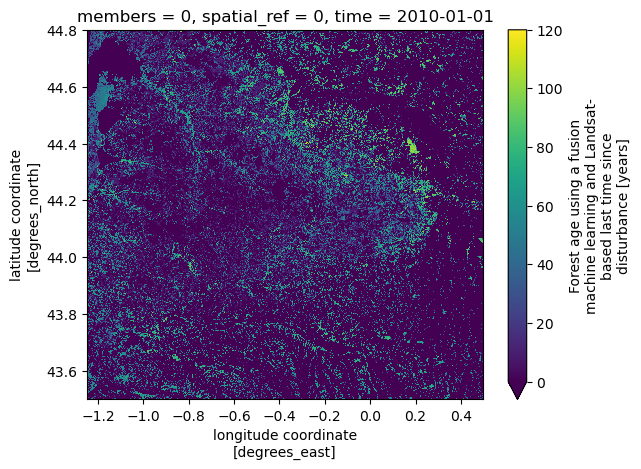

In [6]:
ds["forest_age"].isel(members=0, time=0)[::5, ::5].plot(vmin=0, vmax=120)

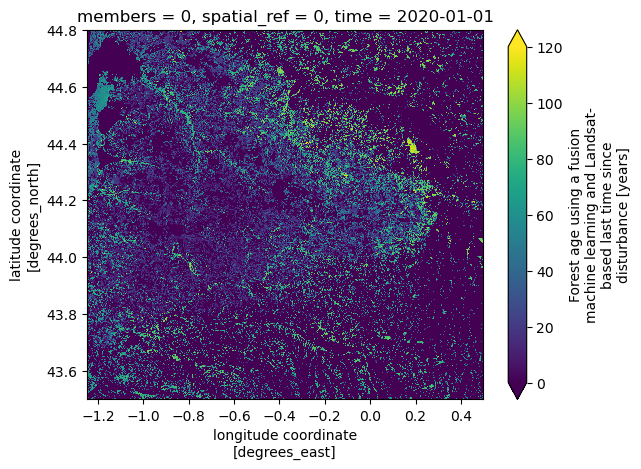

In [7]:
ds["forest_age"].isel(members=0, time=1)[::5, ::5].plot(vmin=0, vmax=120)

In [8]:
ds = msds.stores.storage.open_data("clms.zarr")
ds

<xarray.Dataset> Size: 874MB
Dimensions:             (lat: 5199, lon: 7000)
Coordinates:
  * lat                 (lat) float64 42kB 44.8 44.8 44.8 ... 43.5 43.5 43.5
  * lon                 (lon) float64 56kB -1.25 -1.25 -1.249 ... 0.4996 0.4999
Data variables:
    dominant_leaf_type  (lat, lon) float64 291MB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    forest_type         (lat, lon) float64 291MB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    tree_cover_density  (lat, lon) float64 291MB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
Attributes:
    date_modified:              2025-09-11T15:03:36.475872
    geospatial_bounds:          POLYGON((-1.2167903401501168 43.3252872185624...
    geospatial_bounds_crs:      CRS84
    geospatial_lat_max:         44.972014235360945
    geospatial_lat_min:         43.32528721856248
    geospatial_lat_resolution:  0.00020337497095823664
    geospatial_lat_units:       degrees_north
    geospatial_lon_max:         0.47105574969819175
    geospatial_lon_min:         -1.2167903401501168
    geospatial_lon_resolution:  0.0002149804890727025
    geospatial_lon_units:       degrees_east

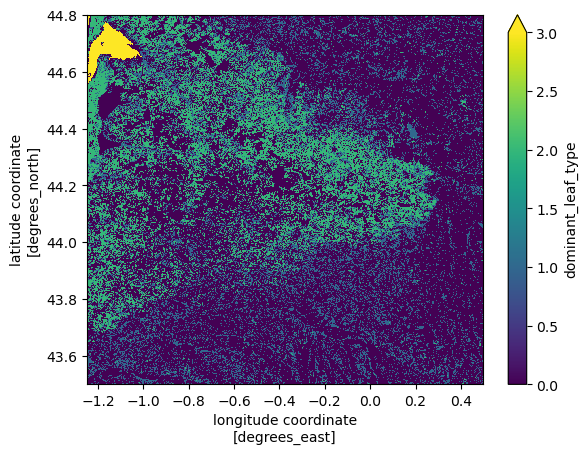

In [9]:
ds["dominant_leaf_type"][::5, ::5].plot(vmax=3)

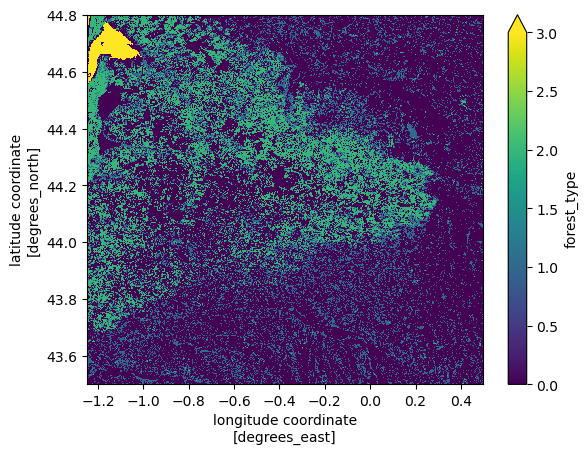

In [10]:
ds["forest_type"][::5, ::5].plot(vmax=3)

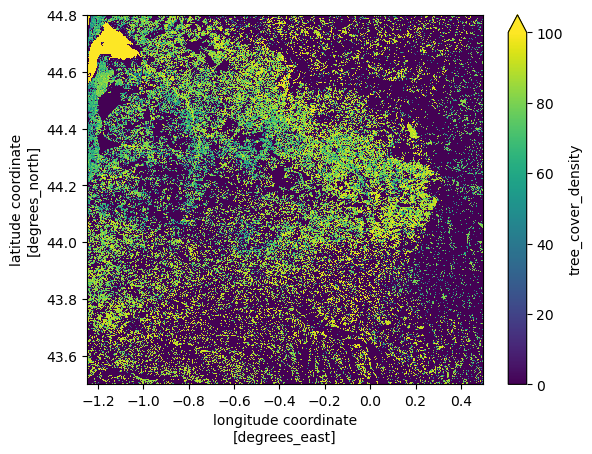

In [11]:
ds["tree_cover_density"][::5, ::5].plot(vmax=100)

In [12]:
ds = msds.stores.storage.open_data("liu.zarr")
ds

<xarray.Dataset> Size: 874MB
Dimensions:        (lat: 5199, lon: 7000)
Coordinates:
  * lat            (lat) float64 42kB 44.8 44.8 44.8 44.8 ... 43.5 43.5 43.5
  * lon            (lon) float64 56kB -1.25 -1.25 -1.249 ... 0.4996 0.4999
Data variables:
    agb            (lat, lon) float64 291MB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    canopy_cover   (lat, lon) float64 291MB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    canopy_height  (lat, lon) float64 291MB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
Attributes:
    date_modified:              2025-09-11T14:52:36.048982
    geospatial_bounds:          POLYGON((-18.9594916134861 50.18279655877187,...
    geospatial_bounds_crs:      CRS84
    geospatial_lat_max:         52.03426577988996
    geospatial_lat_min:         50.18279655877187
    geospatial_lat_resolution:  0.00034892335219183224
    geospatial_lat_units:       degrees_north
    geospatial_lon_max:         -17.63688150306111
    geospatial_lon_min:         -18.9594916134861
    geospatial_lon_resolution:  0.0002391080323462802
    geospatial_lon_units:       degrees_east

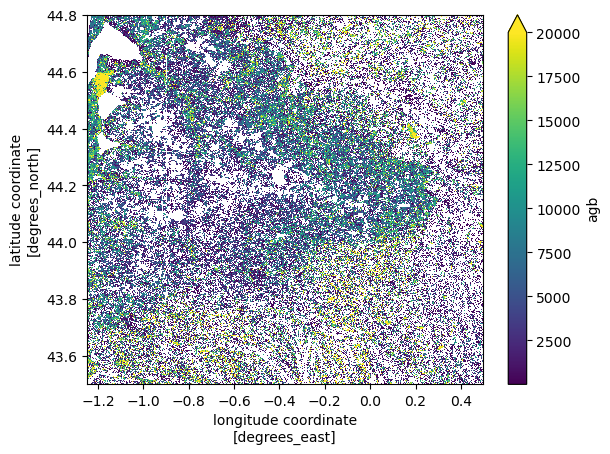

In [13]:
ds["agb"][::5, ::5].plot(vmax=20000)

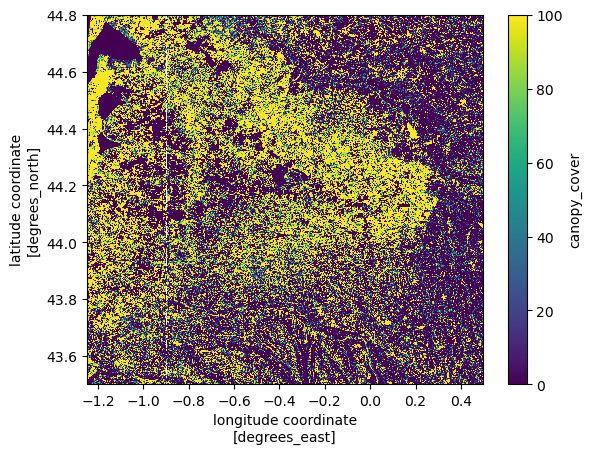

In [14]:
ds["canopy_cover"][::5, ::5].plot()

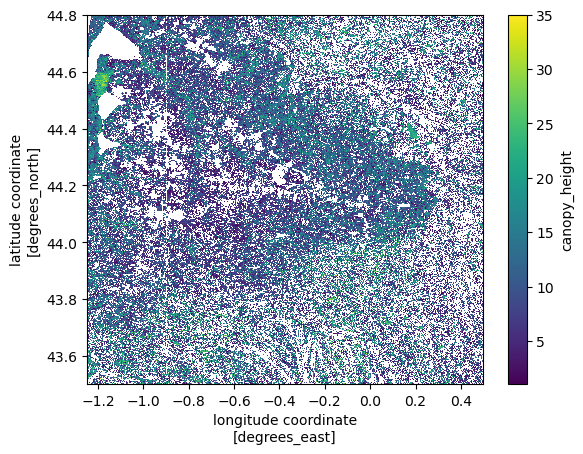

In [15]:
ds["canopy_height"][::5, ::5].plot()

In [16]:
ds = msds.stores.storage.open_data("senf.zarr")
ds

<xarray.Dataset> Size: 47GB
Dimensions:                       (time: 39, lat: 5199, lon: 7000)
Coordinates:
  * lat                           (lat) float64 42kB 44.8 44.8 ... 43.5 43.5
  * lon                           (lon) float64 56kB -1.25 -1.25 ... 0.4999
  * time                          (time) datetime64[ns] 312B 1985-01-01 ... 2...
Data variables:
    annual_disturbances           (time, lat, lon) float64 11GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
    disturbance_agent             (time, lat, lon) float64 11GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
    disturbance_agent_aggregated  (lat, lon) float64 291MB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    disturbance_probability       (time, lat, lon) float64 11GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
    disturbance_severity          (time, lat, lon) float64 11GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
    forest_mask                   (lat, lon) float64 291MB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    greatest_disturbance          (lat, lon) float64 291MB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    latest_disturbance            (lat, lon) float64 291MB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    number_disturbances           (lat, lon) float64 291MB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
Attributes:
    date_modified:              2025-09-11T15:19:16.815048
    geospatial_bounds:          POLYGON((-18.95915690343474 50.18273187952879...
    geospatial_bounds_crs:      CRS84
    geospatial_lat_max:         52.03419759001479
    geospatial_lat_min:         50.182731879528795
    geospatial_lat_resolution:  0.0003489227219688473
    geospatial_lat_units:       degrees_north
    geospatial_lon_max:         -17.6365344971688
    geospatial_lon_min:         -18.95915690343474
    geospatial_lon_resolution:  0.00023911036652535245
    geospatial_lon_units:       degrees_east

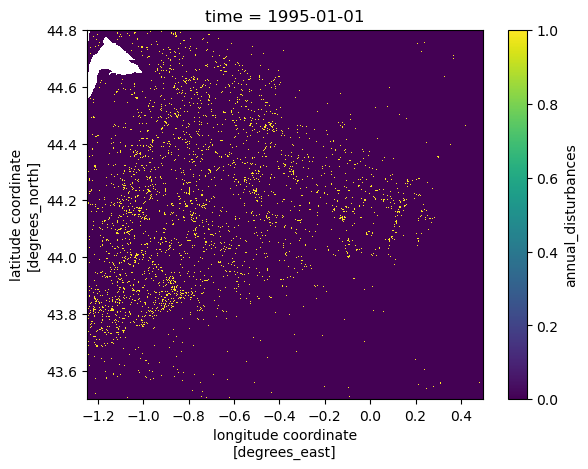

In [17]:
ds["annual_disturbances"].isel(time=10)[::5, ::5].plot()

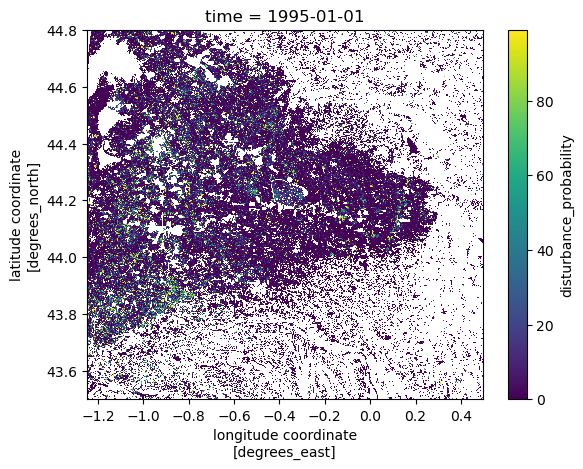

In [18]:
ds["disturbance_probability"].isel(time=10)[::5, ::5].plot()